# Supply Chain Delivery Delay Analytics

## Phase 2: Data Cleaning & Preprocessing

### Objective

The objective of this notebook is to clean the dataset, prepare it for analysis, perform datatype conversion, feature engineering, and validate data quality.

In [37]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns

In [5]:
clean_data = pd.read_csv("../data/processed/supply_chain_cleaned.csv")
clean_data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Order State,Order Status,Order Zipcode,Product Category Id,Product Description,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,Java Occidental,COMPLETE,NaN,73,NaN,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,...,Rajastán,PENDING,NaN,73,NaN,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,...,Rajastán,CLOSED,NaN,73,NaN,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,...,Queensland,COMPLETE,NaN,73,NaN,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,Queensland,PENDING_PAYMENT,NaN,73,NaN,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
clean_data.shape

(180519, 40)

In [7]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Name                  180519 non-null  object 
 8   Customer City                  180519 non-null  object 
 9   Customer Country               180519 non-null  object 
 10  Customer Segment               180519 non-null  object 
 11  Customer State                 180519 non-null  object 
 12  Department Name               

In [9]:
clean_data.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Segment',
 'Customer State',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Category Id',
 'Product Description',
 'Product Name',
 'Product Price',
 'Product Status',
 'shipping date (DateOrders)',
 'Shipping Mode']

## Datatype Conversion

The order date and shipping date are currently stored as object datatype.

To perform time-based analysis and feature engineering, these columns must be converted into datetime format.

In [10]:
clean_data['order date (DateOrders)'] = pd.to_datetime(clean_data['order date (DateOrders)'])

In [11]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Name                  180519 non-null  object        
 8   Customer City                  180519 non-null  object        
 9   Customer Country               180519 non-null  object        
 10  Customer Segment               180519 non-null  object        
 11  

In [13]:
clean_data['shipping date (DateOrders)'] = pd.to_datetime(clean_data['shipping date (DateOrders)'])

In [14]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Name                  180519 non-null  object        
 8   Customer City                  180519 non-null  object        
 9   Customer Country               180519 non-null  object        
 10  Customer Segment               180519 non-null  object        
 11  

##Feature Engineering

In [15]:
clean_data['Order Month'] = clean_data['shipping date (DateOrders)'].dt.month_name()

In [19]:
clean_data['Order Month'].sample(7)

149043       August
174296    September
54770           May
110085     February
74563     September
114480      January
69933       October
Name: Order Month, dtype: object

In [20]:
clean_data['Order Day'] = clean_data['order date (DateOrders)'].dt.day_name()

In [21]:
clean_data['Order Year'] = clean_data['order date (DateOrders)'].dt.year

In [22]:
clean_data['Shipping Month'] = clean_data['shipping date (DateOrders)'].dt.month_name()

In [23]:
clean_data.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Product Description,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Order Month,Order Day,Order Year,Shipping Month
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,NaN,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,February,Wednesday,2018,February
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,...,NaN,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,January,Saturday,2018,January
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,...,NaN,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,January,Saturday,2018,January
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,...,NaN,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,January,Saturday,2018,January
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,NaN,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,January,Saturday,2018,January


In [24]:
clean_data['Shipping Day'] = clean_data['shipping date (DateOrders)'].dt.day_name()

In [25]:
clean_data['Delay Days'] = (
    clean_data['Days for shipping (real)']
    - clean_data['Days for shipment (scheduled)']
)

In [28]:
clean_data['Delay Days'].value_counts().sort_index()

Delay Days
-2    21666
-1    21700
 0    33753
 1    60647
 2    28718
 3     7052
 4     6983
Name: count, dtype: int64

In [29]:
clean_data['Delivery Performance'] = np.where(
    clean_data['Delay Days'] > 0,
    'Delayed',
    np.where(
        clean_data['Delay Days'] == 0,
        'On Time',
        'Early'
    )
)

## Outlier Detection

Outliers are observations that significantly differ from the majority of the data.

However, not every outlier is an error. Some outliers may represent genuine business events.

Therefore, outliers should be investigated before deciding whether to remove or retain them.

In [33]:
clean_data.select_dtypes(include= ["int64", "float64"]).columns

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Latitude', 'Longitude', 'Order Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Zipcode',
       'Product Category Id', 'Product Description', 'Product Price',
       'Product Status', 'Delay Days'],
      dtype='object')

In [34]:
clean_data.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,order date (DateOrders),Order Id,Order Item Discount,...,Order Item Total,Order Profit Per Order,Order Zipcode,Product Category Id,Product Description,Product Price,Product Status,shipping date (DateOrders),Order Year,Delay Days
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,...,180519.000000,180519.000000,24840.000000,180519.000000,0.0,180519.000000,180519.0,180519,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,29.719955,-84.915675,2016-06-12 17:47:04.669868544,36221.894903,20.664741,...,183.107609,21.974989,55426.132327,31.851451,NaN,141.232550,0.0,2016-06-16 05:45:23.202433024,2015.971150,0.565807
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,-33.937553,-158.025986,2015-01-01 00:00:00,1.000000,0.000000,...,7.490000,-4274.979980,1040.000000,2.000000,NaN,9.990000,0.0,2015-01-03 00:00:00,2015.000000,-2.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.265432,-98.446312,2015-09-21 13:49:00,18057.000000,5.400000,...,104.379997,7.000000,23464.000000,18.000000,NaN,50.000000,0.0,2015-09-25 06:59:00,2015.000000,0.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,33.144863,-76.847908,2016-06-11 13:06:00,36140.000000,14.000000,...,163.990005,31.520000,59405.000000,29.000000,NaN,59.990002,0.0,2016-06-15 08:32:00,2016.000000,1.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,39.279617,-66.370583,2017-03-01 08:42:00,54144.000000,29.990000,...,247.399994,64.800003,90008.000000,45.000000,NaN,199.990005,0.0,2017-03-04 21:29:00,2017.000000,1.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,48.781933,115.263077,2018-01-31 23:38:00,77204.000000,500.000000,...,1939.989990,911.799988,99301.000000,76.000000,NaN,1999.989990,0.0,2018-02-06 22:14:00,2018.000000,4.000000
std,1.623722,1.374449,104.433526,120.043670,0.497664,9.813646,21.433241,NaN,21045.379569,21.800901,...,120.043670,104.433526,31919.279101,15.640064,NaN,139.732492,0.0,NaN,0.829429,1.490966


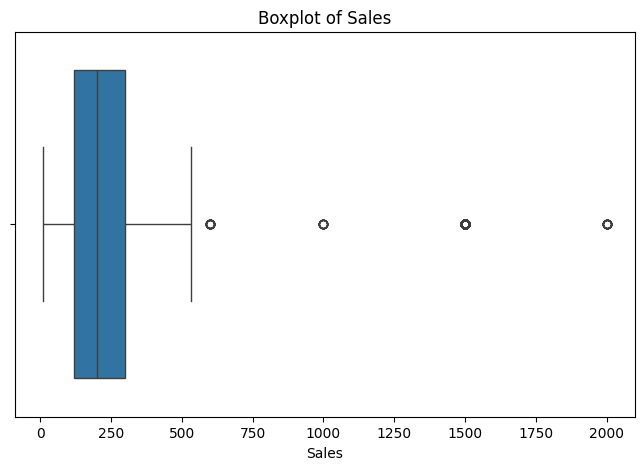

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x=clean_data['Sales'])
plt.title("Boxplot of Sales")
plt.show()

In [39]:
Q1 = clean_data['Sales'].quantile(0.25)
Q3 = clean_data['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

Q1 : 119.9800034
Q3 : 299.9500122
IQR : 179.97000880000002
Lower Limit : -149.97500980000007
Upper Limit : 569.9050254000001


In [40]:
outliers = clean_data[
    (clean_data['Sales'] < lower_limit) |
    (clean_data['Sales'] > upper_limit)
]

print("Total Outliers :", len(outliers))

Total Outliers : 488


In [44]:
outliers[['Product Name', 'Category Name', 'Sales']].sample(10)

,Product Name,Category Name,Sales
168963,Dell Laptop,Computers,1500.00000
122409,Bushnell Pro X7 Jolt Slope Rangefinder,Kids' Golf Clubs,599.98999
63263,Dell Laptop,Computers,1500.00000
68538,Dell Laptop,Computers,1500.00000
8259,Dell Laptop,Computers,1500.00000
21449,Dell Laptop,Computers,1500.00000
12527,Dell Laptop,Computers,1500.00000
82044,Dell Laptop,Computers,1500.00000
93371,Dell Laptop,Computers,1500.00000
40634,Bushnell Pro X7 Jolt Slope Rangefinder,Kids' Golf Clubs,599.98999


### Observation

A total of 488 outliers were detected in the Sales column using the IQR method.

Further investigation showed that these observations correspond to high-value products such as laptops and golf equipment.

These are valid business transactions rather than data entry errors.

Therefore, the outliers were retained in the dataset.

In [45]:
(clean_data['Sales']<0).sum()

0

In [46]:
(clean_data['Product Price']<0).sum()

0

In [47]:
clean_data['Delay Days'].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Delay Days, dtype: float64

In [48]:
(clean_data['Product Price']== 0 ).sum()

0

In [49]:
clean_data['Order Id'].duplicated().sum()

114767

In [50]:
clean_data['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [51]:
clean_data['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [52]:
clean_data[clean_data['Order Id'] == clean_data['Order Id'].iloc[0]]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Product Status,shipping date (DateOrders),Shipping Mode,Order Month,Order Day,Order Year,Shipping Month,Shipping Day,Delay Days,Delivery Performance
0,DEBIT,3,4,91.25,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,0,2018-02-03 22:56:00,Standard Class,February,Wednesday,2018,February,Saturday,-1,Early


In [54]:
clean_data.groupby('Order Id').size().sort_values(ascending=False).head(10)

Order Id
65699    5
42199    5
13260    5
42258    5
42246    5
42243    5
42236    5
13268    5
42222    5
42220    5
dtype: int64

In [55]:
clean_data.shape

(180519, 47)

In [56]:
clean_data.to_csv(
    "../data/processed/supply_chain_cleaned.csv",
    index=False
)

### Validation Result

Duplicate Order IDs were detected.

After investigation, it was observed that a single order can contain multiple products.

Therefore, these are valid business records and not duplicate transactions.

No rows were removed.